In [2]:
import sys
import os

# Comandos complementarios en caso de ejectutar en Colab
if 'google.colab' in sys.modules:

    # Importo funciones.py
    !wget -O funciones.py \
    https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/funciones.py

    # Creo carpeta output
    os.makedirs("output", exist_ok=True)

--2026-08-18 16:34:57--  https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/funciones.py
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/funciones.py [following]
--2026-08-18 16:34:57--  https://raw.githubusercontent.com/francobarrionuevoenv21/MAIE_devs_pub/refs/heads/main/Proc_Img/practicos/funciones.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6329 (6.2K) [text/plain]
Saving to: ‘funciones.py’

funciones.py        100%[===================>]   6.18K  --.-KB/s    in 0s      


In [3]:
# Librerías

## Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.plot import plotting_extent
from rasterio.crs import CRS
from rasterio.mask import mask

# Import funciones.py
import funciones as fn

## Librerías para abrir imágenes desde GitHub como numpy arrays
import requests
import matplotlib.image as mpimg
from PIL import Image
from io import BytesIO

<h3 style="color:red;">Ejercicio 7.a.1- Resolución</h3>

Tu tarea ahora va a ser modificar o crear por fuera de Python tu propio archivo vectorial de muestras (el que tenés de la clase anterior, `muestras_Clase06.gpkg`), y repetir los pasos de la sección 2 para extraer un `DataFrame` y analizar cómo se comportan espectralmente. Podés trabajar con las mismas definiciones de clases , o agrupar / dividir en nuevas en función de cómo veas la separabilidad entre las mismas. Una vez que estés conforme, guardá tu `Dataframe` de muestras como archivo CSV, respetando la estructura de columnas que usamos en la sección anterior. 

De manera resumida, los pasos serían:

- Actualizar / crear archivo vectorial propio de muestras (en QGIS o un programa similar). Guardarlos en formato vectorial
- Leer los vectores en esta Notebook con Geopandas
- Extraer los valores de muestras a un `DataFrame` (*)
- Visualizar las firmas espectrales y/0 los gráficos de separabilidad.
- Guardar el `Dataframe` final como archivo CSV para usar en la Clase 07b. Nombralo como `muestras_Clase07.csv`

El objetivo de este ejercicio es que luego de haber tomado una primera versión de las muestras en la clase 06, y pensando ahora en un escenario de aprendizaje supervisado, armes tu propia base de datos para trabajar con los clasificadores.

(*) Para agilizar la extracción de muestras a partir de los vectores, dejamos sistematizada una función. Agregala a tu archivo `funciones.py`:

In [4]:
# Importo los rois para el muestreo y visualizo el dataframe
rois_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/muestras_drog.gpkg'
rois_vec = gpd.read_file(rois_path)
rois_vec.sample(10)

,id,clase,geometry
20,NaN,vegetacion,"MULTIPOLYGON (((-58.82018 -34.71604, -58.82014..."
21,NaN,vegetacion,"MULTIPOLYGON (((-58.80219 -34.69984, -58.80216..."
2,3.0,agua,"MULTIPOLYGON (((-58.86504 -34.69719, -58.865 -..."
7,NaN,suel_desn,"MULTIPOLYGON (((-58.87845 -34.70994, -58.87841..."
5,6.0,agua,"MULTIPOLYGON (((-58.91231 -34.69817, -58.9123 ..."
15,NaN,urbano,"MULTIPOLYGON (((-58.81585 -34.66499, -58.81581..."
1,2.0,agua,"MULTIPOLYGON (((-58.88775 -34.69571, -58.88772..."
12,NaN,urbano,"MULTIPOLYGON (((-58.78352 -34.72021, -58.78354..."
10,NaN,suel_desn,"MULTIPOLYGON (((-58.8338 -34.72482, -58.83377 ..."
8,NaN,suel_desn,"MULTIPOLYGON (((-58.91226 -34.6777, -58.91223 ..."


1181.0 2360.0
1281.0 2612.0
1227.0 2762.0
1306.0 5528.0
1079.0 4588.0
1068.0 3971.0


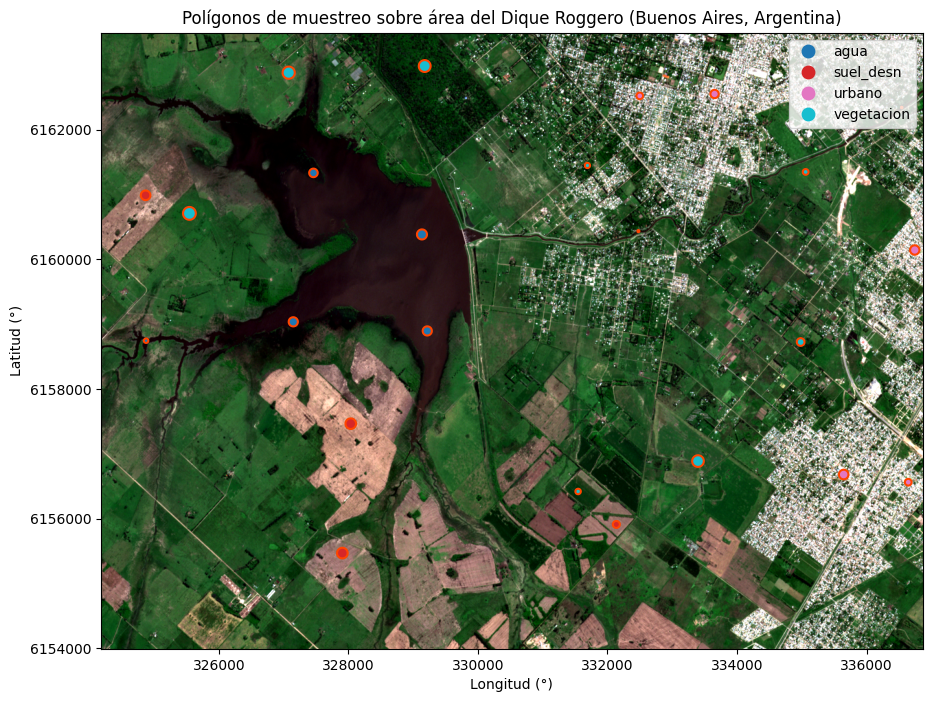

In [10]:
# Recupero el stack de bandas de la escena de S2 con todas las bandas
path_imagen = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006.tif'

# Visualizo junto a los polígonos de muestreo
with rasterio.open(path_imagen) as src:
    img = src.read()
    extent = plotting_extent(src) 

# Escalamos la imagen para visualizar
imagen_escalada = fn.scale_multiband(img, p=2)

# Reproyecto el archivo vectorial
rois_vec = rois_vec.to_crs(epsg=32721)

# Ploteamos la imagen con los vectores superpuestos
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(imagen_escalada[[2,1,0]].transpose(1,2,0), extent = extent)
rois_vec.plot(ax=ax, column='clase', legend = True)
rois_vec.boundary.plot(ax=ax, color='orangered')
ax.ticklabel_format(style='plain')

# Etiquetas y título
ax.set_ylabel('Latitud (°)')
ax.set_xlabel('Longitud (°)')
ax.set_title('Polígonos de muestreo sobre área del Dique Roggero (Buenos Aires, Argentina)')

plt.show()

In [11]:
# Defino las bandas del stack a extraer
list_bands = ['B02', 'B03','B04', 'B08', 'B11', 'B12']

df_muestras = fn.extraer_muestras(path_imagen, rois_vec, nodata = 65535, bandas = list_bands)

# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(list_bands)

# Esta línea arma un nombre de archivo de salida con las bandas elegidas
nombre_archivo = f'output/Clase07a_muestras_{nombre_bandas}.csv'

# Guardo como .csv
df_muestras.to_csv(nombre_archivo)

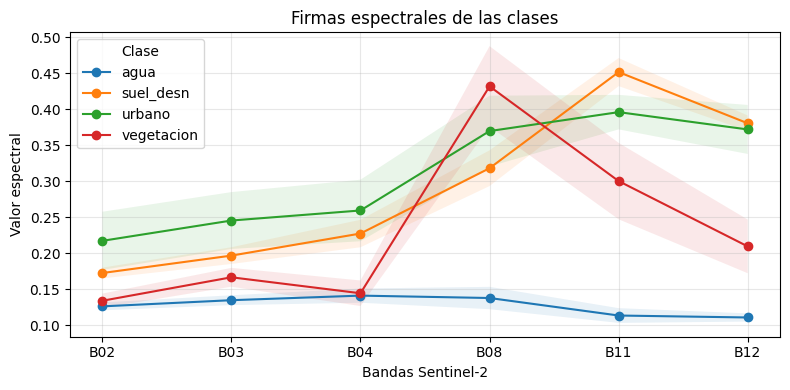

In [12]:
# Recupero .csv con muestras desde GitHub
if 'google.colab' in sys.modules:
    df_muestras = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_B02_B03_B04_B08_B11_B12.csv'

# Ploteo la firma espectral de las muestras
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)

muestras = pd.read_csv(df_muestras)
muestras = muestras.drop(columns=['Unnamed: 0'])
bandas = muestras.columns[:-1]
    
for clase, grupo in muestras.groupby('Clase'):

    datos_clase = grupo[bandas] / 10000 # Dividimos por 10000 para que los valores queden expresados entre 0 y 1

    media_clase = datos_clase.mean(axis=0).to_numpy()
    std_clase = datos_clase.std(axis=0).to_numpy()

    ax.plot(bandas, media_clase, marker='o', label=clase)

    ax.fill_between(bandas, media_clase - std_clase, media_clase + std_clase, alpha=0.1)

ax.set_xlabel('Bandas Sentinel-2')
ax.set_ylabel('Valor espectral')
ax.set_title('Firmas espectrales de las clases')

ax.legend(title='Clase')
ax.grid(alpha=0.3)

plt.show()

<h3 style="color:red;">Ejercicio 7.a.2- Resolución</h3>

Repetí la misma actividad del ejercicio anterior, pero esta vez leyendo el ráster que guardaste en la Clase 06 con un subconjunto de bandas menor (`output/S2_20181006_{bandas}_Clase06.tif`). Guarda el archivo CSV de muestras como `output/Muestras_Clase07_{bandas}`, donde `{bandas}` es el listado descriptivo de bandas que elegiste para armar ese ráster. Lo vas a utilizar en la Clase 07 para comparar cómo le fue a tu clasificador con este subconjunto de bandas.

In [13]:
# Creo una lista de paths con las direcciones los stacks de la escena de S2
list_paths = ['https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B04_B08_B11.tif',
              'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B08_B11.tif',
              'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B08_B11_B12.tif']

# Creo una lista de listas con las bandas a seleccionar de cada stack
list_bands = [['B02', 'B03','B04', 'B08', 'B11'],
              ['B02', 'B03', 'B08', 'B11'],
              ['B02', 'B03', 'B08', 'B11', 'B12']]

In [14]:
# Genero un csv con las muestras por cada stack
list_outputs = []

for i, p in enumerate(list_paths):
    df_muestras = fn.extraer_muestras(list_paths[i], rois_vec, nodata = 65535, bandas = list_bands[i])

    # Esta línea "concatena" los textos de la lista separados por un "_"
    nombre_bandas = "_".join(list_bands[i])

    # Esta línea arma un nombre de archivo de salida con las bandas elegidas
    nombre_archivo = f'output/Clase07a_muestras_{nombre_bandas}.csv'
    list_outputs.append(nombre_archivo)

    # Guardo como .csv
    df_muestras.to_csv(nombre_archivo)

In [1]:
# Recupero .csv con muestras desde GitHub
if 'google.colab' in sys.modules:
    list_outputs = ['https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_B02_B03_B04_B08_B11.csv',
    'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_B02_B03_B08_B11.csv',
    'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_B02_B03_B08_B11_B12.csv']

fig, ax = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)

for i, path in enumerate(list_outputs):

    muestras = pd.read_csv(list_outputs[i])
    muestras = muestras.drop(columns=['Unnamed: 0'])
    bandas = muestras.columns[:-1]
    
    for clase, grupo in muestras.groupby('Clase'):


        datos_clase = grupo[bandas] / 10000 # Dividimos por 10000 para que los valores queden expresados entre 0 y 1

        media_clase = datos_clase.mean(axis=0).to_numpy()
        std_clase = datos_clase.std(axis=0).to_numpy()

        ax[i].plot(bandas, media_clase, marker='o', label=clase)

        ax[i].fill_between(bandas, media_clase - std_clase, media_clase + std_clase, alpha=0.1)

    ax[i].set_xlabel('Bandas Sentinel-2')
    ax[i].set_ylabel('Valor espectral')
    ax[i].set_title('Firmas espectrales de las clases')

    ax[i].legend(title='Clase')
    ax[i].grid(alpha=0.3)

plt.show()

NameError: name 'sys' is not defined

<h2 style="color:red;">Ejercicio 7.b.1- Resolución</h2>

Ya contamos con los modelos seleccionados para **KNN** y **Random Forest**, utilizando los mejores hiperparámetros encontrados durante la etapa de validación cruzada:

- `modelo_KNN_elegido`
- `modelo_RF_elegido`

Estos modelos ya están instanciados con sus respectivos hiperparámetros óptimos, pero todavía falta realizar su **entrenamiento definitivo utilizando todas las muestras disponibles**.

Para cada uno de ellos:

1. Entrená el modelo utilizando todas las muestras (`X` e `Y`):

```python
modelo_elegido.fit(X, Y)
```

2. Utilizá el modelo entrenado para clasificar todos los píxeles de la imagen, siguiendo el mismo procedimiento utilizado anteriormente con **Decision Tree**.

3. Reconstruí la imagen clasificada con las dimensiones espaciales originales.

4. Visualizá el mapa resultante.

5. Guardá el mapa obtenido como archivo **GeoTIFF**.

Realizá este procedimiento primero para `modelo_KNN_elegido` y luego para `modelo_RF_elegido`. Opcionalmente, podés generar el archivo QML con las clases correspondientes para su visualización en QGIS.

In [ ]:
# Importo scikit learn 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [5]:
# Importamos muestras de ejemplo desde GitHub
path_muestras = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_ejemplo.csv'
muestras = pd.read_csv(path_muestras)
muestras.sample(10)

,Unnamed: 0,B02,B03,B04,B08,B11,B12,Clase
3250,3250,1240.0,1470.0,1276.0,3964.0,2521.0,1810.0,vegetacion
168,168,1229.0,1288.0,1402.0,1262.0,1104.0,1103.0,agua
1046,1046,1697.0,1902.0,2172.0,3030.0,4462.0,3969.0,suel_desn
2401,2401,1516.0,1871.0,1814.0,4060.0,3789.0,2790.0,vegetacion
3246,3246,1273.0,1619.0,1314.0,5004.0,2727.0,1908.0,vegetacion
1991,1991,2726.0,2814.0,3076.0,3604.0,4082.0,3939.0,urbano
1234,1234,1658.0,1866.0,2082.0,3120.0,4374.0,3724.0,suel_desn
2604,2604,1232.0,1558.0,1254.0,4216.0,2314.0,1648.0,vegetacion
1536,1536,2904.0,3486.0,3676.0,4802.0,4396.0,3897.0,urbano
666,666,1275.0,1353.0,1440.0,1335.0,1078.0,1070.0,agua


In [13]:
# Ordeno y genero el dataset para entrenamiento del modelo

# Obtengo y asigno ID a las clases
clases=list(set(muestras['Clase']))
clases.sort() # ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

# Crear la columna numérica
muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)

# Obtengo un numpy array con los datos de las variables predictoras y predicho
columnas_x = ['B02','B03','B04','B08','B11', 'B12']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()

# Aplico un split de los datos
X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)


In [15]:
# Defino los hiperparámetros obtenidos previamente

# Mejor KNN
best_K = 3

# Mejor RF
best_prof_dt = 5
best_estim_rf = 100

In [ ]:
# Modelo KNN

# Instanceo el modelo KNN
modelo_KNN_elegido = KNeighborsClassifier(n_neighbors=best_K)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_KNN_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_KNN = modelo_KNN_elegido.predict(X_val)

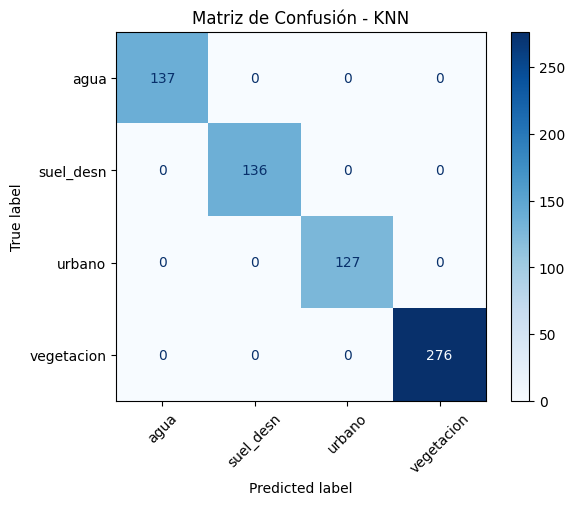

In [17]:
# Matriz de confusión

M_KNN = confusion_matrix(Y_val, Y_pred_KNN, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_KNN, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - KNN")
plt.show()

In [18]:
# Instanceo el modelo RF
modelo_RF_elegido = RandomForestClassifier(n_estimators=best_estim_rf, max_depth=best_prof_dt, random_state=42)

# Entrenamos utilizando las muestras del conjunto de entrenamiento
modelo_RF_elegido.fit(X_train, Y_train)

# Predecimos las clases del conjunto de validación
Y_pred_RF = modelo_RF_elegido.predict(X_val)

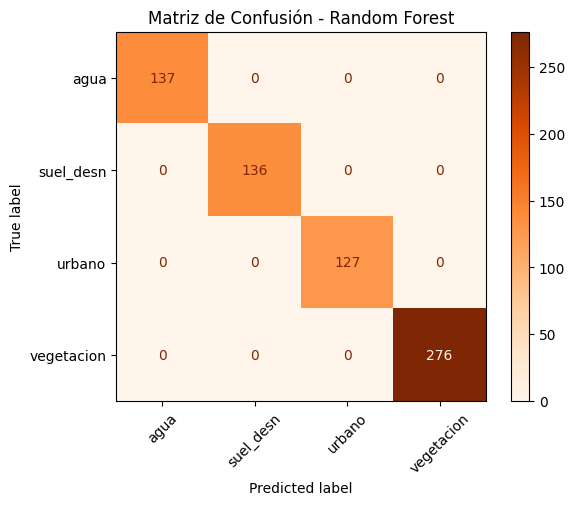

In [19]:
# Matriz de Confusión
M_RF = confusion_matrix(Y_val, Y_pred_RF)

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF, display_labels=clases)

disp.plot(cmap='Oranges', xticks_rotation=45)
plt.title("Matriz de Confusión - Random Forest")
plt.show()

In [20]:
# Ajusto los modelos definidos con todos los datos

# Modelo KNN
modelo_KNN_elegido.fit(X, Y)

# Modelo RF
modelo_RF_elegido.fit(X, Y)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# Recupero la imagen de la escena de S2, abro y obtengo las dimensiones

path_imagen = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006.tif'

with rasterio.open(path_imagen) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape

In [23]:
# Predicción sobre la escena S2

# Modelo KNN
Y_pred_KNN = modelo_KNN_elegido.predict(img.reshape([d,x*y]).T)

# Modelo RF
Y_pred_RF = modelo_RF_elegido.predict(img.reshape([d,x*y]).T)

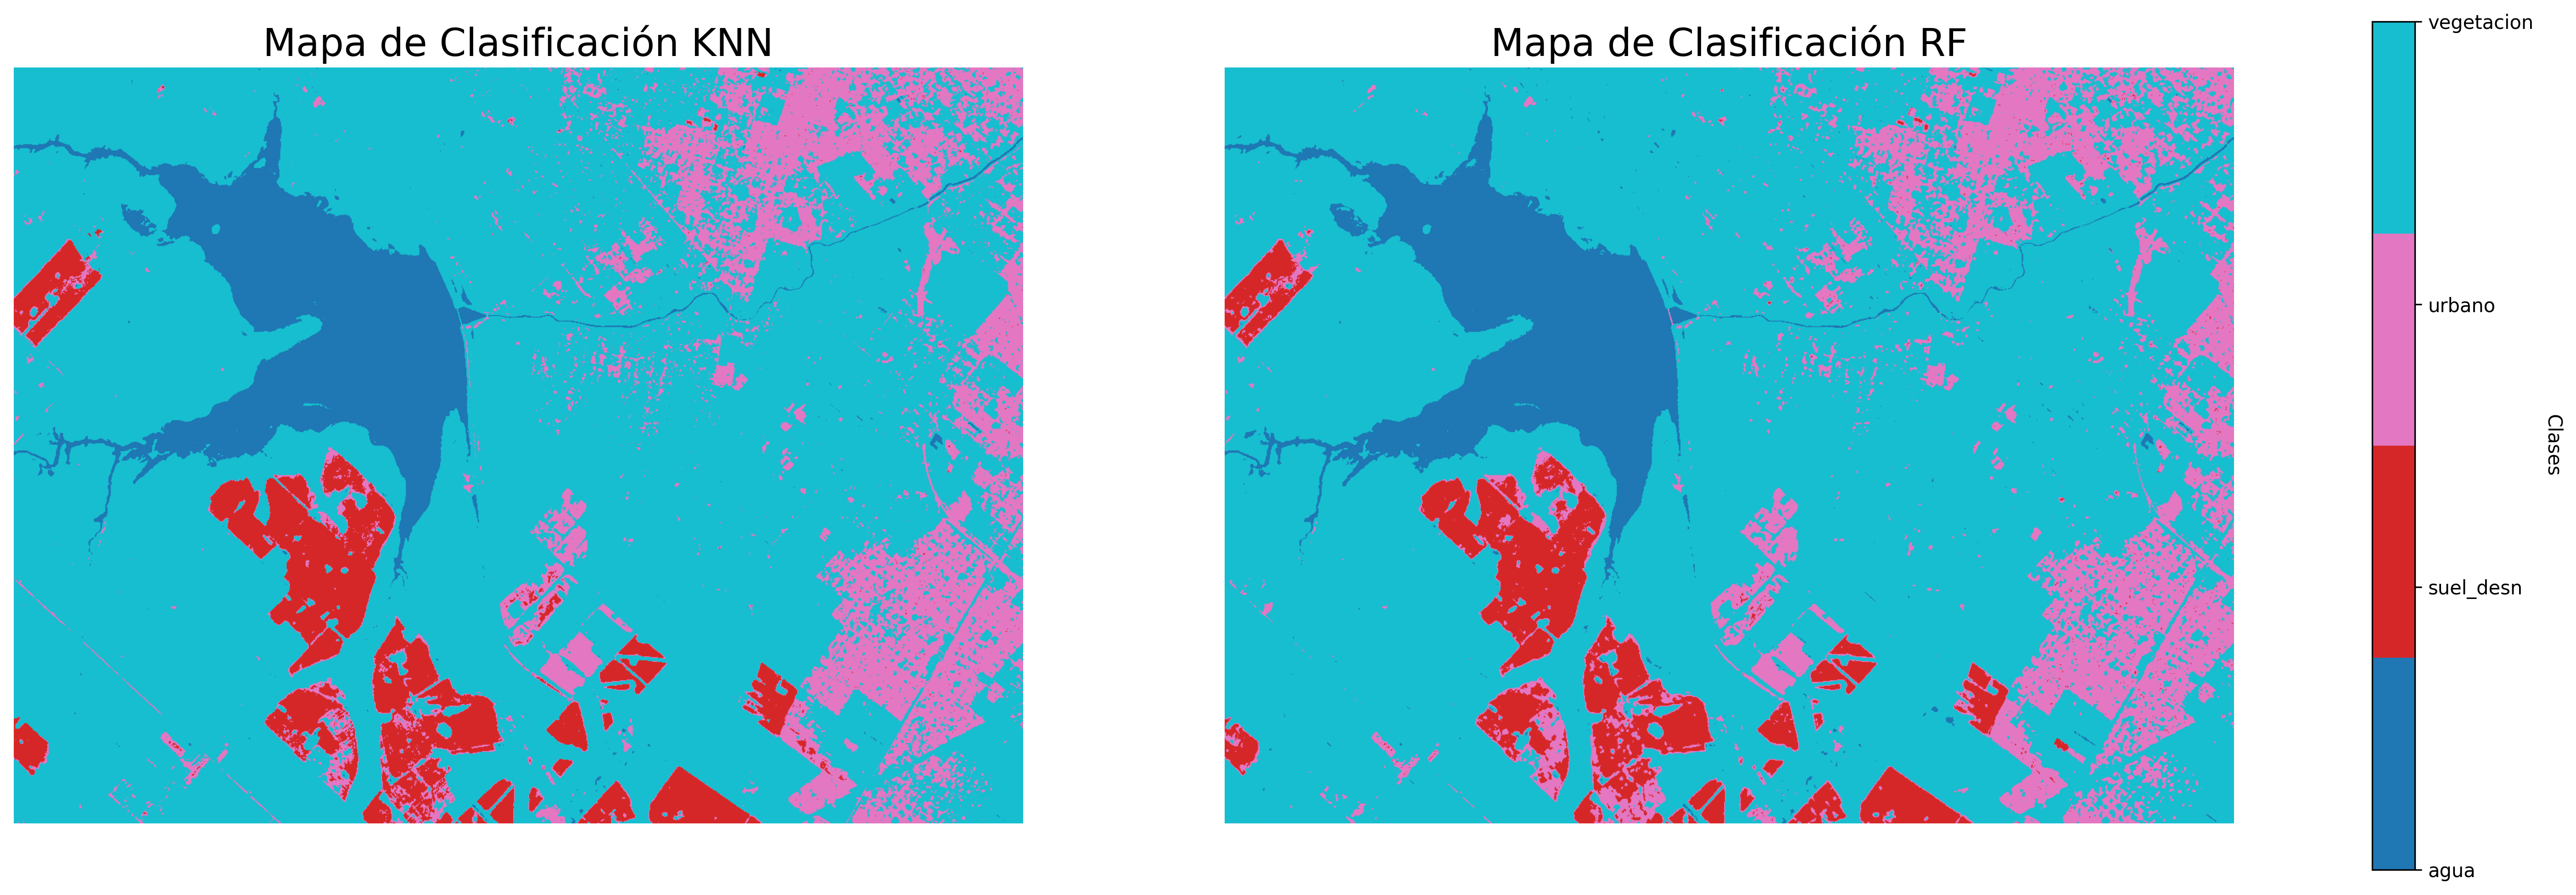

In [24]:
# Reconstrucción del el mapa clasificado

# Reshape de las predicciones
class_img_KNN = Y_pred_KNN.reshape([x, y])
class_img_RF = Y_pred_RF.reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(1, 2, figsize=(26, 8), dpi=300)

im1 = ax[0].imshow(class_img_KNN, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)
im2 = ax[1].imshow(class_img_RF, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im1, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax[0].set_title("Mapa de Clasificación KNN", fontsize=20)
ax[0].axis('off')
ax[1].set_title("Mapa de Clasificación RF", fontsize=20)
ax[1].axis('off')

plt.show()

In [25]:
# Genero una copia de los metadatos de la imagen original
metadatos_clasif = metadatos.copy()

# Actualizo la cantidad de bandas, y el tipo de dato (no hace falta trabajar a 16 bits)
metadatos_clasif['count'] = 1
metadatos_clasif['dtype'] = 'uint8'
#Guardo un resultado

# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(columnas_x)

out_fn_KNN = f'Class_IMG_{nombre_bandas}_CLF_KNN.tif'
out_fn_RF = f'Class_IMG_{nombre_bandas}_CLF_RF.tif'

# Guardo mapa resultados KNN
with rasterio.open(f'output/{out_fn_KNN}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_KNN, 1)

# Guardo mapa resultados RF
with rasterio.open(f'output/{out_fn_RF}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_RF, 1)

<h2 style="color:red;">Ejercicio 7.b.2- Resolución</h2>

Entrená un clasificador utilizando **uno de los tres algoritmos trabajados en esta clase** (KNN, Decision Tree o Random Forest). Utilizá como datos de entrada la imagen con el conjunto reducido de bandas que generaste en la **Clase 06** y las muestras correspondientes que preparaste en la **Clase 07a**.

Siguiendo el procedimiento desarrollado en esta clase:

1. Realizá una búsqueda del **hiperparámetro óptimo** del algoritmo seleccionado mediante validación cruzada.
2. Evaluá el modelo elegido y reportá sus **métricas de desempeño**, incluyendo la Matriz de Confusión.
3. Entrená el modelo definitivo utilizando todas las muestras disponibles.
4. Aplicá el modelo entrenado sobre la imagen completa para generar el mapa clasificado.
5. Guardá el resultado como un archivo **GeoTIFF**.

In [27]:
# Recupero los datos de muestreo del stack de bandas de la escena
# de S2 sobre el Dique Roggero con las bandas 2, 3, 8 y 11

# Importamos muestras de ejemplo desde GitHub
path_muestras = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/Clase07a_muestras_B02_B03_B08_B11.csv'
muestras = pd.read_csv(path_muestras)
muestras.sample(10)

# Extraigo los datos para el entrenamiento de los modelos (idem 7.a.1)
clases=list(set(muestras['Clase']))
clases.sort() #ordeno las clases de mi CSV alfabéticamente
clase_dict = {clase:i for i, clase in enumerate(clases)}

muestras['Clase_ID'] = muestras['Clase'].map(clase_dict)

columnas_x = ['B02','B03','B08','B11']
X = muestras[columnas_x].to_numpy()
Y = muestras['Clase_ID'].to_numpy()

# Aplico un split de los datos
X_train, X_val, Y_train, Y_val = train_test_split(X ,Y ,test_size=0.2, stratify=Y, random_state=42)

In [28]:
# Inicializo el modelo base
rf = RandomForestClassifier(random_state=42)

# Defino la grilla de parámetros para hallar la mejor combinación
param_grid = {
    'n_estimators': [5, 10, 25, 50, 100, 200, 300, 400, 500],
    'max_depth': np.arange(2, 25),
}

# Defino el Grid Search de hiperparámetros con 5 folds para validación
n_splits = 5
cv_strategy = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv_strategy, scoring='accuracy', n_jobs=-1)

# Obtengo los mejores hiperparámetros
grid_search.fit(X_train, Y_train)

# Extraigo los mejores hiperparámetros hallados
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Intanceo el modelo RF hallado
best_rf_model = grid_search.best_estimator_

Best Parameters: {'max_depth': np.int64(7), 'n_estimators': 25}
Best CV Score: 0.9926


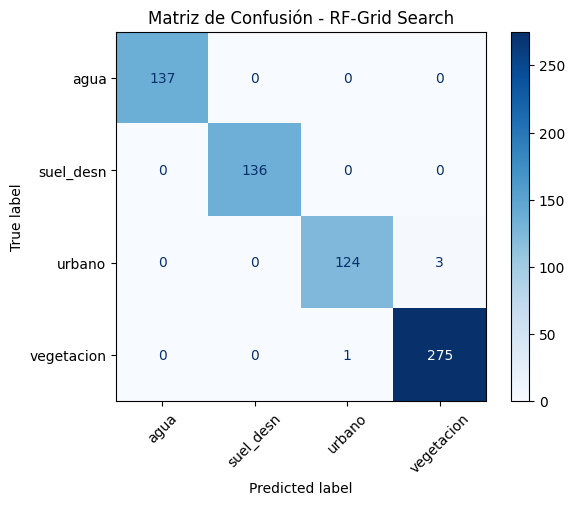

In [29]:
# Evaluación de la performance del modelo

# Predecimos las clases del conjunto de validación
Y_pred_RF2 = best_rf_model.predict(X_val)

# Matriz de confusión
M_RF2 = confusion_matrix(Y_val, Y_pred_RF2, labels=range(len(clases)))

disp = ConfusionMatrixDisplay(confusion_matrix=M_RF2, display_labels=clases)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Matriz de Confusión - RF-Grid Search")
plt.show()

In [31]:
# Recupero la imagen de la escena de S2, abro y obtengo las dimensiones
path_imagen = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B08_B11.tif'

with rasterio.open(path_imagen) as src:
    img = src.read()
    metadatos = src.meta

d, x, y = img.shape

(np.float64(-0.5), np.float64(1268.5), np.float64(950.5), np.float64(-0.5))

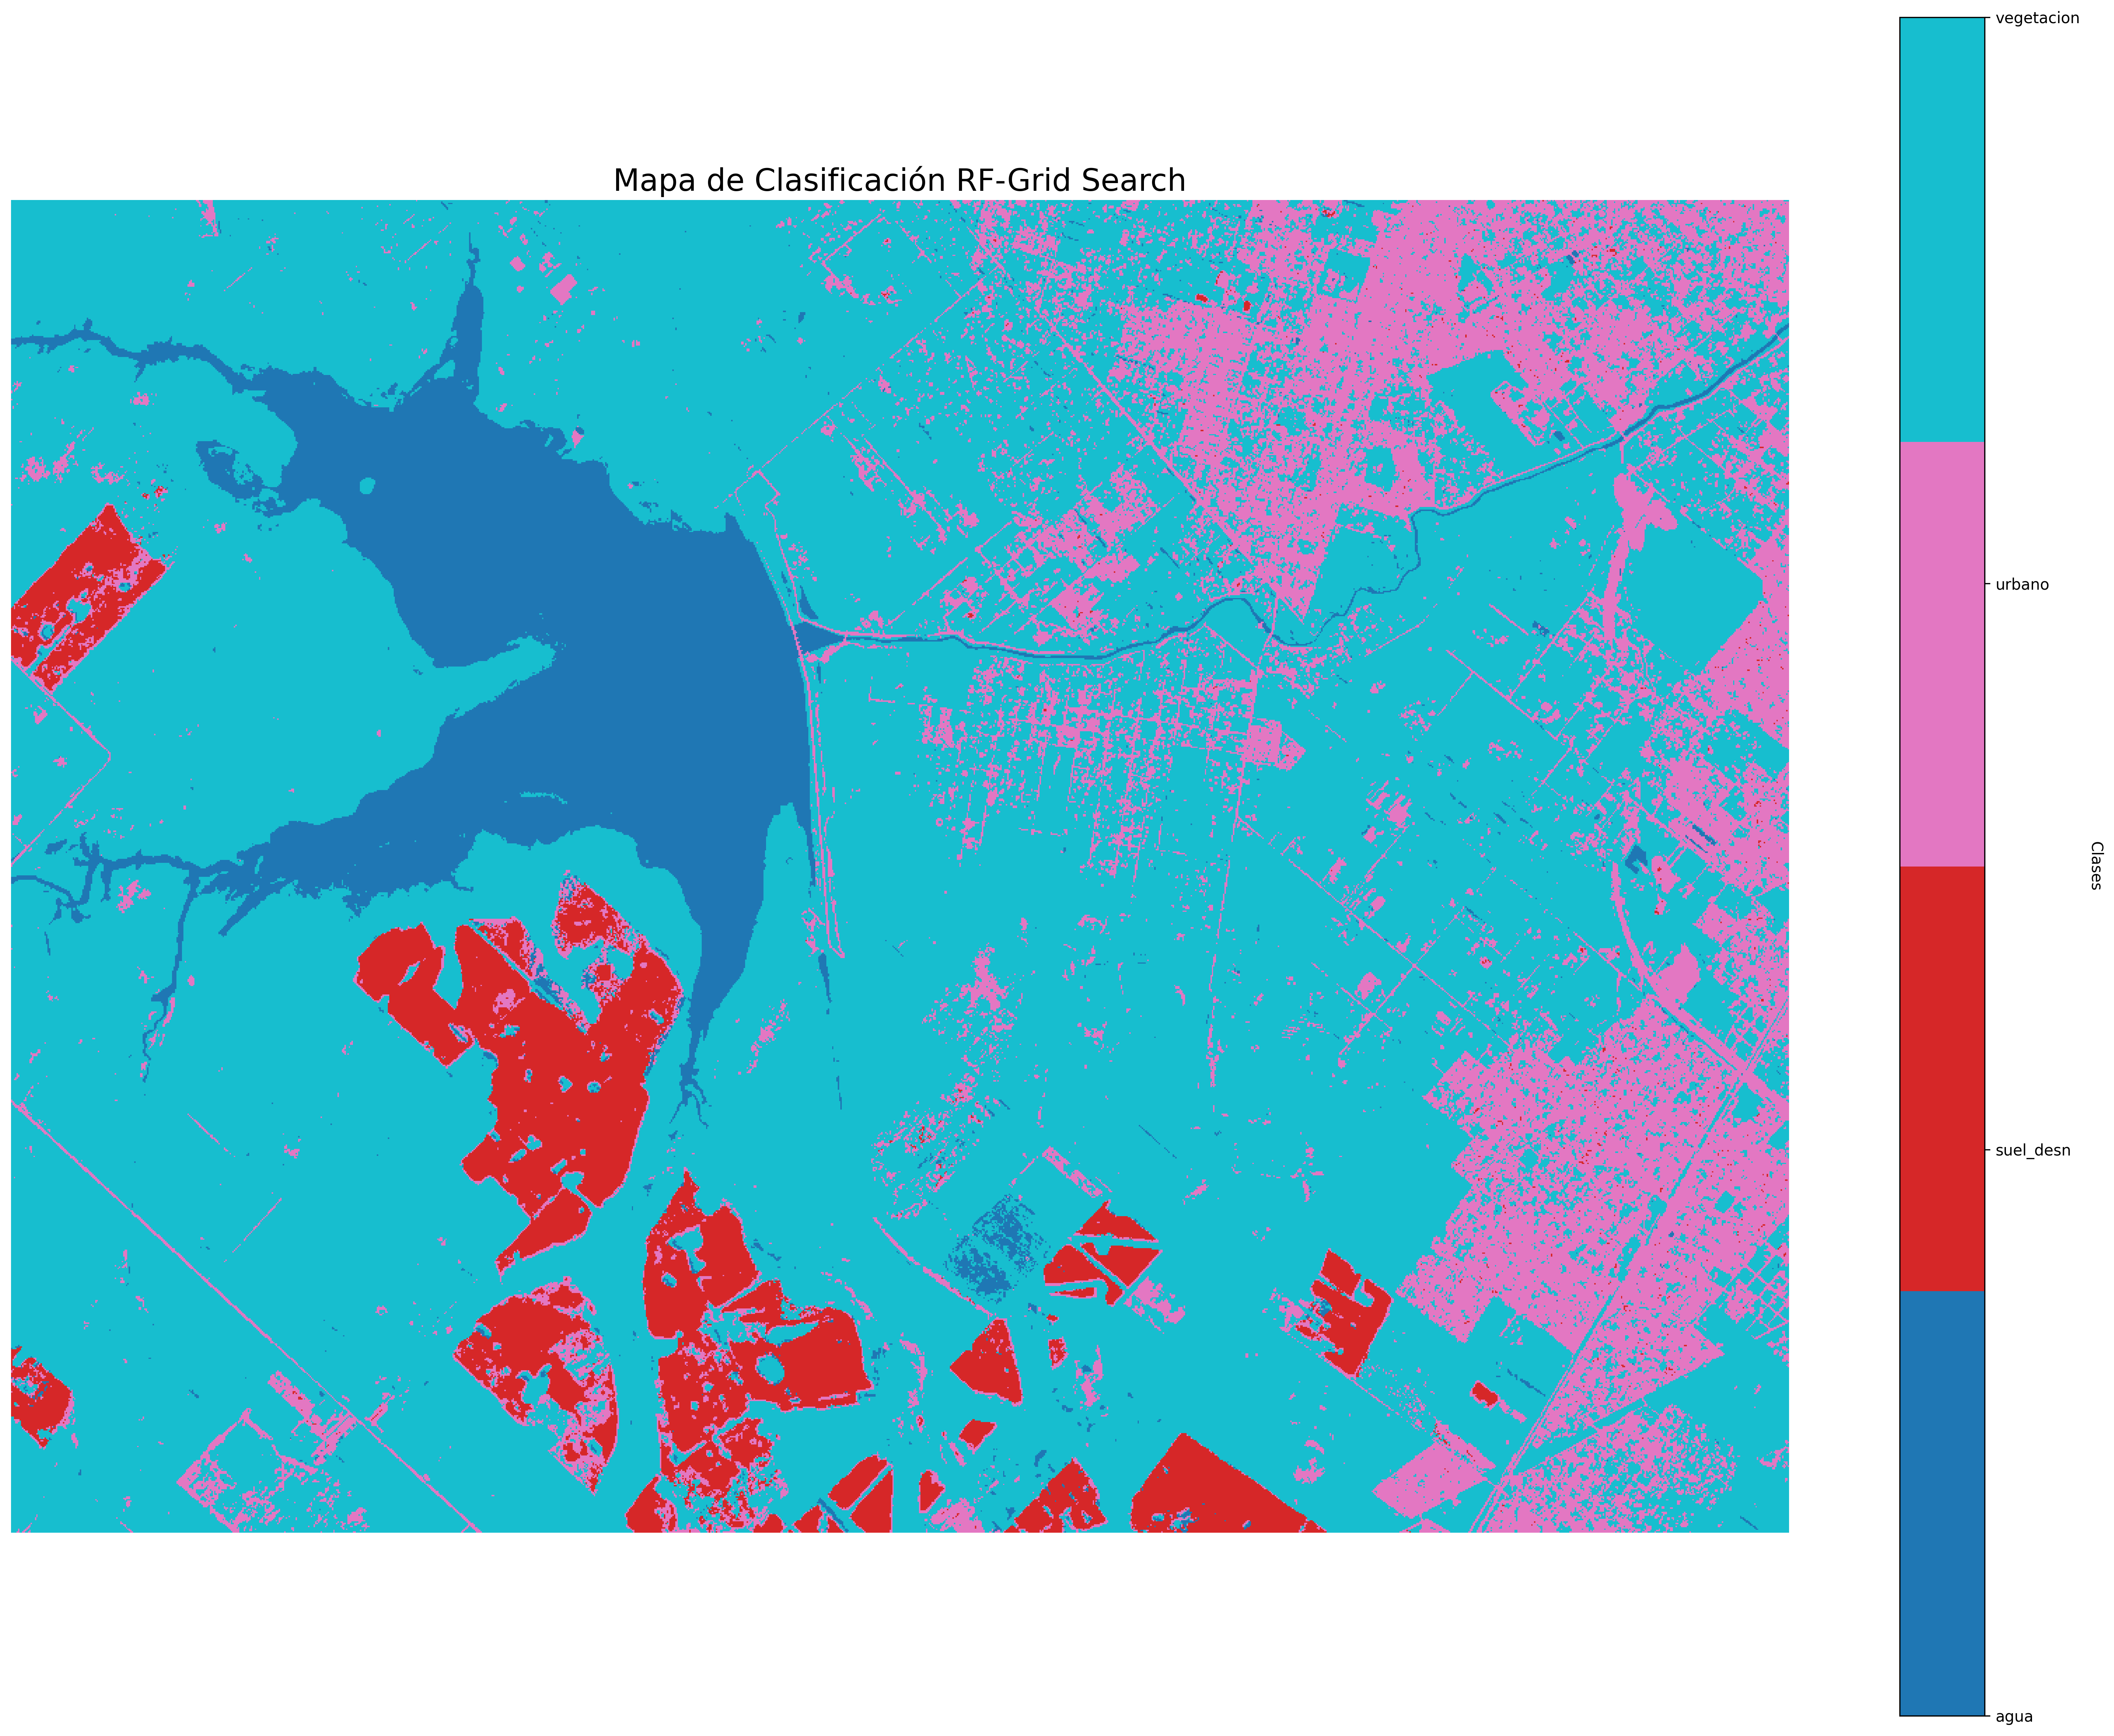

In [33]:
# Reconstruimos el mapa clasificado
Y_pred_RF2 = best_rf_model.predict(img.reshape([d,x*y]).T).reshape([x, y])

# Lista de etiquetas ordenadas por índice
etiquetas = clases

# Crear un mapa de colores categórico en función de la cantidad de clases
cmap = plt.get_cmap('tab10', len(etiquetas))

fig, ax = plt.subplots(figsize=(26, 20), dpi=300)

im = ax.imshow(Y_pred_RF2, cmap=cmap, vmin=0, vmax=len(etiquetas) - 1)

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(etiquetas)))
cbar.ax.set_yticklabels(etiquetas)
cbar.set_label('Clases', rotation=270, labelpad=15)

ax.set_title("Mapa de Clasificación RF-Grid Search", fontsize=20)
ax.axis('off')

In [34]:
# Genero una copia de los metadatos de la imagen original
metadatos_clasif = metadatos.copy()

# Actualizo la cantidad de bandas, y el tipo de dato (no hace falta trabajar a 16 bits)
metadatos_clasif['count'] = 1
metadatos_clasif['dtype'] = 'uint8'
#Guardo un resultado

# Esta línea "concatena" los textos de la lista separados por un "_"
nombre_bandas = "_".join(columnas_x)

out_fn_KNN = f'Class_IMG_{nombre_bandas}_CLF_RF-GS.tif'

# Guardo mapa resultados KNN
with rasterio.open(f'output/{out_fn_KNN}', 'w', **metadatos_clasif) as dst:
    dst.write(class_img_KNN, 1)